In [40]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
from faker import Faker

# Initialize Faker for realistic data generation
!pip install faker -q
fake = Faker()

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)

print("="*80)
print("CREATING SHOPSTREAM DATA TABLES")
print("="*80)

CREATING SHOPSTREAM DATA TABLES


In [41]:
print("\n1. Creating raw_user_interactions table...")

# Define number of events
n_events = 1000

# Generate realistic timestamps (last 90 days)
end_date = datetime.now()
start_date = end_date - timedelta(days=90)

# Create timestamps with realistic patterns (more events during peak hours)
def generate_timestamp(start, end, peak_hours=True):
    """Generate timestamps with realistic patterns"""
    timestamp = fake.date_time_between(start_date=start, end_date=end)

    # Adjust for peak hours (more events during 10 AM - 8 PM)
    if peak_hours:
        hour = timestamp.hour
        if 10 <= hour <= 20:
            # 80% chance to keep, 20% chance to regenerate
            if random.random() > 0.8:
                return generate_timestamp(start, end, peak_hours)

    return timestamp

# Generate user IDs (200 unique users)
user_ids = [f"U-{i:04d}" for i in range(1, 201)]

# Action types with weights (more common actions have higher probability)
actions = ['play', 'like', 'skip', 'share', 'purchase', 'refund']
action_weights = [0.65, 0.15, 0.10, 0.05, 0.04, 0.01]

# Content types
content_types = ['show', 'movie', 'episode', 'premium-plan', 'basic-plan', 'trial-plan']
content_ids = []
for i in range(1, 101):
    content_type = random.choice(content_types[:3])  # shows, movies, episodes
    content_ids.append(f"{content_type}-{i}")

# Add premium content IDs
for i in range(1, 11):
    content_ids.append(f"premium-plan-{i}")
    content_ids.append(f"basic-plan-{i}")

# Devices
devices = ['web', 'mobile', 'tv', 'tablet']
device_weights = [0.45, 0.30, 0.15, 0.10]

# Countries (realistic distribution)
countries = ['US', 'DE', 'JP', 'FR', 'GB', 'CA', 'AU', 'BR', 'IN', 'ES']
country_weights = [0.40, 0.15, 0.10, 0.08, 0.07, 0.05, 0.05, 0.04, 0.03, 0.03]

# Generate data
data = {
    'event_id': [],
    'user_id': [],
    'action': [],
    'content_id': [],
    'amount': [],
    'device': [],
    'country': [],
    'event_timestamp': [],
    '_loaded_at': []
}

for i in range(n_events):
    # Generate event_id
    event_id = f"evt-{i+1:04d}"

    # Generate user_id (some users are more active)
    user_id = random.choices(user_ids, weights=[1.0] * len(user_ids))[0]

    # Generate action
    action = random.choices(actions, weights=action_weights)[0]

    # Generate content_id based on action
    if action in ['purchase', 'refund']:
        # Premium content for transactions
        content_id = random.choice([c for c in content_ids if 'plan' in c])
    else:
        # Regular content for interactions
        content_id = random.choice([c for c in content_ids if 'plan' not in c])

    # Generate amount (only for purchases and refunds)
    amount = None
    if action == 'purchase':
        if 'premium' in content_id:
            amount = round(random.uniform(10.0, 30.0), 2)
        elif 'basic' in content_id:
            amount = round(random.uniform(5.0, 15.0), 2)
        else:
            amount = round(random.uniform(0.99, 9.99), 2)
    elif action == 'refund':
        amount = round(random.uniform(5.0, 25.0), 2)

    # Generate device
    device = random.choices(devices, weights=device_weights)[0]

    # Generate country
    country = random.choices(countries, weights=country_weights)[0]

    # Generate timestamp
    timestamp = generate_timestamp(start_date, end_date)

    # Loaded timestamp (slightly after event timestamp)
    loaded_at = timestamp + timedelta(seconds=random.randint(1, 300))

    # Add to data
    data['event_id'].append(event_id)
    data['user_id'].append(user_id)
    data['action'].append(action)
    data['content_id'].append(content_id)
    data['amount'].append(amount)
    data['device'].append(device)
    data['country'].append(country)
    data['event_timestamp'].append(timestamp)
    data['_loaded_at'].append(loaded_at)

# Create DataFrame
raw_user_interactions = pd.DataFrame(data)

print(f"✓ Created raw_user_interactions with {len(raw_user_interactions):,} rows")
print(f"  Columns: {list(raw_user_interactions.columns)}")
print(f"  Date range: {raw_user_interactions['event_timestamp'].min()} to {raw_user_interactions['event_timestamp'].max()}")
print(f"  Actions: {raw_user_interactions['action'].value_counts().to_dict()}")


1. Creating raw_user_interactions table...
✓ Created raw_user_interactions with 1,000 rows
  Columns: ['event_id', 'user_id', 'action', 'content_id', 'amount', 'device', 'country', 'event_timestamp', '_loaded_at']
  Date range: 2025-12-23 19:24:34.155961 to 2026-03-23 17:00:09.610638
  Actions: {'play': 634, 'like': 160, 'skip': 108, 'share': 49, 'purchase': 32, 'refund': 17}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [44]:
print("\n2. Creating dim_users dimension table...")

# Get unique users from interactions
unique_users = raw_user_interactions['user_id'].unique()

# Generate dimension data
user_data = {
    'user_id': [],
    'user_segment': [],
    'signup_date': [],
    'is_premium': [],
    'country': [],
    '_updated_at': []
}

# User segments
segments = ['premium_whale', 'premium_standard', 'new_user', 'trial_user', 'free_user']
segment_weights = [0.05, 0.15, 0.20, 0.25, 0.35]

# Generate dates for signups (up to 1 year ago)
start_signup = end_date - timedelta(days=365)

# Convert end_date to date for comparison (FIX)
end_date_date = end_date.date()

for user_id in unique_users:
    # Determine if premium (30% chance for premium users)
    is_premium = random.random() < 0.3

    # Signup date (random between 1 year ago and today)
    # Convert to date to match type (FIX)
    signup_date = fake.date_between(start_date=start_signup.date(), end_date=end_date.date())

    # Calculate days since signup (using date objects) (FIX)
    days_since_signup = (end_date_date - signup_date).days

    # Determine user segment
    if is_premium:
        # Premium users have higher spend potential
        total_spend = raw_user_interactions[
            (raw_user_interactions['user_id'] == user_id) &
            (raw_user_interactions['action'] == 'purchase')
        ]['amount'].sum()

        if total_spend > 100:
            segment = 'premium_whale'
        else:
            segment = 'premium_standard'
    else:
        if days_since_signup <= 7:
            segment = 'new_user'
        elif days_since_signup <= 30:
            segment = 'trial_user'
        else:
            segment = 'free_user'

    # Get primary country (most frequent)
    user_country = raw_user_interactions[raw_user_interactions['user_id'] == user_id]['country'].mode()
    if len(user_country) > 0:
        country = user_country[0]
    else:
        country = random.choice(countries)

    # Add to data
    user_data['user_id'].append(user_id)
    user_data['user_segment'].append(segment)
    user_data['signup_date'].append(signup_date)
    user_data['is_premium'].append(is_premium)
    user_data['country'].append(country)
    user_data['_updated_at'].append(datetime.now())

# Create DataFrame
dim_users = pd.DataFrame(user_data)

print(f"✓ Created dim_users with {len(dim_users):,} rows")
print(f"  Segment distribution:\n{dim_users['user_segment'].value_counts()}")
print(f"  Premium users: {dim_users['is_premium'].sum():,}")


2. Creating dim_users dimension table...
✓ Created dim_users with 200 rows
  Segment distribution:
user_segment
free_user           135
premium_standard     50
trial_user           12
new_user              3
Name: count, dtype: int64
  Premium users: 50


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [43]:
print("\n3. Creating fct_daily_engagement fact table...")

# Create date range (last 30 days)
date_range = pd.date_range(end=end_date.date(), periods=30, freq='D')
date_range = [d.date() for d in date_range]

# Aggregate daily engagement metrics
engagement_data = {
    'date_key': [],
    'user_id': [],
    'total_events': [],
    'play_count': [],
    'purchase_count': [],
    'revenue': [],
    'engagement_score': [],
    '_loaded_at': []
}

# Convert timestamp to date for grouping
raw_user_interactions['event_date'] = raw_user_interactions['event_timestamp'].dt.date

# For each user and each day
for user_id in unique_users[:100]:  # Limit to 100 users for performance
    user_events = raw_user_interactions[raw_user_interactions['user_id'] == user_id]

    for date in date_range:
        # Events for this user on this date
        daily_events = user_events[user_events['event_date'] == date]

        if len(daily_events) > 0:
            # Calculate metrics
            total_events = len(daily_events)
            play_count = len(daily_events[daily_events['action'] == 'play'])
            purchase_count = len(daily_events[daily_events['action'] == 'purchase'])
            revenue = daily_events[daily_events['action'] == 'purchase']['amount'].sum()

            # Calculate engagement score
            like_count = len(daily_events[daily_events['action'] == 'like'])
            share_count = len(daily_events[daily_events['action'] == 'share'])
            skip_count = len(daily_events[daily_events['action'] == 'skip'])

            # Calculate engagement score (0-100)
            if total_events > 0:
                positive = play_count + (like_count * 2) + (share_count * 3)
                negative = skip_count
                raw_score = (positive - negative) / total_events * 100
                engagement_score = max(0, min(100, round(raw_score, 2)))
            else:
                engagement_score = 0

            # Add to data
            engagement_data['date_key'].append(date)
            engagement_data['user_id'].append(user_id)
            engagement_data['total_events'].append(total_events)
            engagement_data['play_count'].append(play_count)
            engagement_data['purchase_count'].append(purchase_count)
            engagement_data['revenue'].append(revenue if not pd.isna(revenue) else 0)
            engagement_data['engagement_score'].append(engagement_score)
            engagement_data['_loaded_at'].append(datetime.now())

# Create DataFrame
fct_daily_engagement = pd.DataFrame(engagement_data)

print(f"✓ Created fct_daily_engagement with {len(fct_daily_engagement):,} rows")
print(f"  Unique users: {fct_daily_engagement['user_id'].nunique():,}")
print(f"  Unique dates: {fct_daily_engagement['date_key'].nunique():,}")
print(f"  Total revenue: ${fct_daily_engagement['revenue'].sum():,.2f}")


3. Creating fct_daily_engagement fact table...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✓ Created fct_daily_engagement with 182 rows
  Unique users: 84
  Unique dates: 30
  Total revenue: $115.02


In [50]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Install pandasql if not already installed
!pip install pandasql -q
from pandasql import sqldf

print("="*80)
print("STREAMPULSE DATA PROFILING REPORT")
print("="*80)
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

  Preparing metadata (setup.py) ... done
STREAMPULSE DATA PROFILING REPORT
Generated: 2026-03-23 18:23:01


In [51]:
## Step 1: Complete Null Analysis for raw_user_interactions
print("\n" + "="*80)
print("ITERATION 1: COMPLETENESS ANALYSIS")
print("="*80)

# Step 1: Null Value Analysis
print("\nStep 1: Null Value Analysis")

null_analysis_query = """
SELECT
    COUNT(*) as total_rows,

    -- Per-column null analysis
    COUNT(event_id) as event_id_present,
    ROUND((COUNT(*) - COUNT(event_id)) * 100.0 / COUNT(*), 4) as event_id_null_pct,

    COUNT(user_id) as user_id_present,
    ROUND((COUNT(*) - COUNT(user_id)) * 100.0 / COUNT(*), 4) as user_id_null_pct,

    COUNT(action) as action_present,
    ROUND((COUNT(*) - COUNT(action)) * 100.0 / COUNT(*), 4) as action_null_pct,

    COUNT(content_id) as content_id_present,
    ROUND((COUNT(*) - COUNT(content_id)) * 100.0 / COUNT(*), 4) as content_id_null_pct,

    COUNT(amount) as amount_present,
    ROUND((COUNT(*) - COUNT(amount)) * 100.0 / COUNT(*), 4) as amount_null_pct,

    COUNT(device) as device_present,
    ROUND((COUNT(*) - COUNT(device)) * 100.0 / COUNT(*), 4) as device_null_pct,

    COUNT(country) as country_present,
    ROUND((COUNT(*) - COUNT(country)) * 100.0 / COUNT(*), 4) as country_null_pct,

    COUNT(event_timestamp) as timestamp_present,
    ROUND((COUNT(*) - COUNT(event_timestamp)) * 100.0 / COUNT(*), 4) as timestamp_null_pct

FROM raw_user_interactions
"""

null_results = sqldf(null_analysis_query, locals())
print("\nNull Analysis Results:")
display(null_results)


ITERATION 1: COMPLETENESS ANALYSIS

Step 1: Null Value Analysis

Null Analysis Results:


,total_rows,event_id_present,event_id_null_pct,user_id_present,user_id_null_pct,action_present,action_null_pct,content_id_present,content_id_null_pct,amount_present,amount_null_pct,device_present,device_null_pct,country_present,country_null_pct,timestamp_present,timestamp_null_pct
0,1000,1000,0.0,1000,0.0,1000,0.0,1000,0.0,49,95.1,1000,0.0,1000,0.0,1000,0.0


In [52]:
# Step 2: Empty String Detection
print("\nStep 2: Empty String Detection")

empty_string_query = """
SELECT
    COUNT(CASE WHEN user_id = '' THEN 1 END) as user_id_empty,
    COUNT(CASE WHEN action = '' THEN 1 END) as action_empty,
    COUNT(CASE WHEN content_id = '' THEN 1 END) as content_id_empty,
    COUNT(CASE WHEN country = '' THEN 1 END) as country_empty,
    COUNT(CASE WHEN device = '' THEN 1 END) as device_empty
FROM raw_user_interactions
"""

empty_results = sqldf(empty_string_query, locals())
print("Empty String Analysis:")
display(empty_results)




Step 2: Empty String Detection
Empty String Analysis:


,user_id_empty,action_empty,content_id_empty,country_empty,device_empty
0,0,0,0,0,0


In [53]:
# Step 3: Completeness Report
print("\nStep 3: Completeness Report")

completeness_report = []
for col in raw_user_interactions.columns:
    total_rows = len(raw_user_interactions)
    null_count = raw_user_interactions[col].isna().sum()
    null_pct = (null_count / total_rows) * 100

    # Empty string count for string columns
    empty_count = 0
    empty_pct = 0
    if raw_user_interactions[col].dtype == 'object':
        empty_count = (raw_user_interactions[col] == '').sum()
        empty_pct = (empty_count / total_rows) * 100

    total_missing = null_count + empty_count
    total_missing_pct = (total_missing / total_rows) * 100

    # Determine status and recommendation
    if total_missing_pct == 0:
        status = "✅ COMPLETE"
        recommendation = "No action needed"
    elif total_missing_pct < 5:
        status = "⚠️ ACCEPTABLE"
        recommendation = "Monitor for increases"
    elif total_missing_pct < 20:
        status = "⚠️ CONCERNING"
        recommendation = "Investigate source"
    else:
        status = "❌ CRITICAL"
        recommendation = "Requires immediate attention"

    completeness_report.append({
        'Column': col,
        'Null %': round(null_pct, 2),
        'Empty %': round(empty_pct, 2) if empty_pct > 0 else 'N/A',
        'Total Missing %': round(total_missing_pct, 2),
        'Status': status,
        'Recommendation': recommendation
    })

completeness_df = pd.DataFrame(completeness_report)
print("\nCompleteness Summary:")
display(completeness_df)


Step 3: Completeness Report

Completeness Summary:


,Column,Null %,Empty %,Total Missing %,Status,Recommendation
0,event_id,0.0,N/A,0.0,✅ COMPLETE,No action needed
1,user_id,0.0,N/A,0.0,✅ COMPLETE,No action needed
2,action,0.0,N/A,0.0,✅ COMPLETE,No action needed
3,content_id,0.0,N/A,0.0,✅ COMPLETE,No action needed
4,amount,95.1,N/A,95.1,❌ CRITICAL,Requires immediate attention
5,device,0.0,N/A,0.0,✅ COMPLETE,No action needed
6,country,0.0,N/A,0.0,✅ COMPLETE,No action needed
7,event_timestamp,0.0,N/A,0.0,✅ COMPLETE,No action needed
8,_loaded_at,0.0,N/A,0.0,✅ COMPLETE,No action needed
9,event_date,0.0,N/A,0.0,✅ COMPLETE,No action needed


In [54]:
# Iteration 2: Uniqueness & Distribution
# Step 4: Cardinality Analysis
print("\nStep 4: Cardinality Analysis")

cardinality_query = """
SELECT
    COUNT(*) as total_rows,
    COUNT(DISTINCT event_id) as distinct_event_ids,
    COUNT(*) - COUNT(DISTINCT event_id) as duplicate_event_ids,
    COUNT(DISTINCT user_id) as distinct_users,
    ROUND(COUNT(DISTINCT user_id) * 1.0 / NULLIF(COUNT(user_id), 0), 6) as user_id_cardinality,
    COUNT(DISTINCT action) as distinct_actions,
    COUNT(DISTINCT content_id) as distinct_content,
    COUNT(DISTINCT device) as distinct_devices,
    COUNT(DISTINCT country) as distinct_countries
FROM raw_user_interactions
WHERE user_id IS NOT NULL AND user_id != ''
"""

cardinality_results = sqldf(cardinality_query, locals())
print("Cardinality Analysis:")
display(cardinality_results)



Step 4: Cardinality Analysis
Cardinality Analysis:


,total_rows,distinct_event_ids,duplicate_event_ids,distinct_users,user_id_cardinality,distinct_actions,distinct_content,distinct_devices,distinct_countries
0,1000,1000,0,200,0.2,6,118,4,10


In [56]:
# Step 5: Numeric Distribution (amount)
print("\nStep 5: Numeric Distribution (amount)")
import numpy as np
numeric_dist_query = """
SELECT
    COUNT(amount) as non_null_count,
    MIN(amount) as min_amount,
    MAX(amount) as max_amount,
    ROUND(AVG(amount), 2) as mean_amount,
    ROUND(STDDEV(amount), 2) as stddev_amount,
    ROUND(PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY amount), 2) as p10,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY amount), 2) as p25,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY amount), 2) as median,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY amount), 2) as p75,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY amount), 2) as p90,
    ROUND(PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY amount), 2) as p99,
    COUNT(CASE WHEN amount < 0 THEN 1 END) as negative_count,
    COUNT(CASE WHEN amount = 0 THEN 1 END) as zero_count
FROM raw_user_interactions
WHERE amount IS NOT NULL
"""

numeric_results = sqldf(numeric_dist_query, locals())
print("Amount Distribution:")
display(numeric_results)



Step 5: Numeric Distribution (amount)


PandaSQLException: (sqlite3.OperationalError) near "WITHIN": syntax error
[SQL: 
SELECT
    COUNT(amount) as non_null_count,
    MIN(amount) as min_amount,
    MAX(amount) as max_amount,
    ROUND(AVG(amount), 2) as mean_amount,
    ROUND(STDDEV(amount), 2) as stddev_amount,
    ROUND(PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY amount), 2) as p10,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY amount), 2) as p25,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY amount), 2) as median,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY amount), 2) as p75,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY amount), 2) as p90,
    ROUND(PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY amount), 2) as p99,
    COUNT(CASE WHEN amount < 0 THEN 1 END) as negative_count,
    COUNT(CASE WHEN amount = 0 THEN 1 END) as zero_count
FROM raw_user_interactions
WHERE amount IS NOT NULL
]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [57]:
# Step 6: Categorical Distribution (action, device, country)
print("\nStep 6: Categorical Distribution")

# Action distribution
action_query = """
SELECT action, COUNT(*) as count,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
FROM raw_user_interactions
WHERE action IS NOT NULL AND action != ''
GROUP BY action
ORDER BY count DESC
"""

print("\nAction Distribution:")
action_results = sqldf(action_query, locals())
display(action_results)

# Device distribution
device_query = """
SELECT device, COUNT(*) as count,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
FROM raw_user_interactions
WHERE device IS NOT NULL AND device != ''
GROUP BY device
ORDER BY count DESC
"""

print("\nDevice Distribution:")
device_results = sqldf(device_query, locals())
display(device_results)

# Top 10 countries
country_query = """
SELECT country, COUNT(*) as count,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
FROM raw_user_interactions
WHERE country IS NOT NULL AND country != ''
GROUP BY country
ORDER BY count DESC
LIMIT 10
"""

print("\nTop 10 Countries:")
country_results = sqldf(country_query, locals())
display(country_results)


Step 6: Categorical Distribution

Action Distribution:


,action,count,pct
0,play,634,63.4
1,like,160,16.0
2,skip,108,10.8
3,share,49,4.9
4,purchase,32,3.2
5,refund,17,1.7



Device Distribution:


,device,count,pct
0,web,426,42.6
1,mobile,330,33.0
2,tv,149,14.9
3,tablet,95,9.5



Top 10 Countries:


,country,count,pct
0,US,399,39.9
1,DE,149,14.9
2,JP,93,9.3
3,GB,90,9.0
4,FR,72,7.2
5,AU,44,4.4
6,CA,44,4.4
7,BR,43,4.3
8,IN,39,3.9
9,ES,27,2.7


In [58]:
# Step 7: Daily Volume Trend
print("\nStep 7: Daily Volume Trend")

# Convert to datetime if needed
raw_user_interactions['event_timestamp'] = pd.to_datetime(raw_user_interactions['event_timestamp'])
raw_user_interactions['event_date'] = raw_user_interactions['event_timestamp'].dt.date

daily_trend = raw_user_interactions.groupby('event_date').agg({
    'event_id': 'count',
    'user_id': 'nunique',
    'amount': lambda x: x[raw_user_interactions['action'] == 'purchase'].sum()
}).reset_index()

daily_trend.columns = ['event_date', 'daily_events', 'daily_users', 'daily_revenue']

# Calculate day-over-day change
daily_trend['prev_day_events'] = daily_trend['daily_events'].shift(1)
daily_trend['day_over_day_change'] = ((daily_trend['daily_events'] - daily_trend['prev_day_events']) /
                                        daily_trend['prev_day_events'] * 100).round(2)

print("Daily Volume Trend (Last 30 days):")
display(daily_trend.tail(10))


Step 7: Daily Volume Trend
Daily Volume Trend (Last 30 days):


,event_date,daily_events,daily_users,daily_revenue,prev_day_events,day_over_day_change
81,2026-03-14,14,14,0.00,11.0,27.27
82,2026-03-15,9,9,0.00,14.0,-35.71
83,2026-03-16,18,18,9.49,9.0,100.00
84,2026-03-17,8,8,0.00,18.0,-55.56
85,2026-03-18,15,15,0.00,8.0,87.50
86,2026-03-19,11,10,0.00,15.0,-26.67
87,2026-03-20,18,18,0.00,11.0,63.64
88,2026-03-21,12,11,0.00,18.0,-33.33
89,2026-03-22,7,7,0.00,12.0,-41.67
90,2026-03-23,9,8,21.30,7.0,28.57



Step 8: Hourly Pattern
Hourly Pattern:


,hour_of_day,event_count,pct
0,0,48,4.8
1,1,59,5.9
2,2,46,4.6
3,3,47,4.7
4,4,53,5.3
5,5,48,4.8
6,6,39,3.9
7,7,42,4.2
8,8,47,4.7
9,9,55,5.5


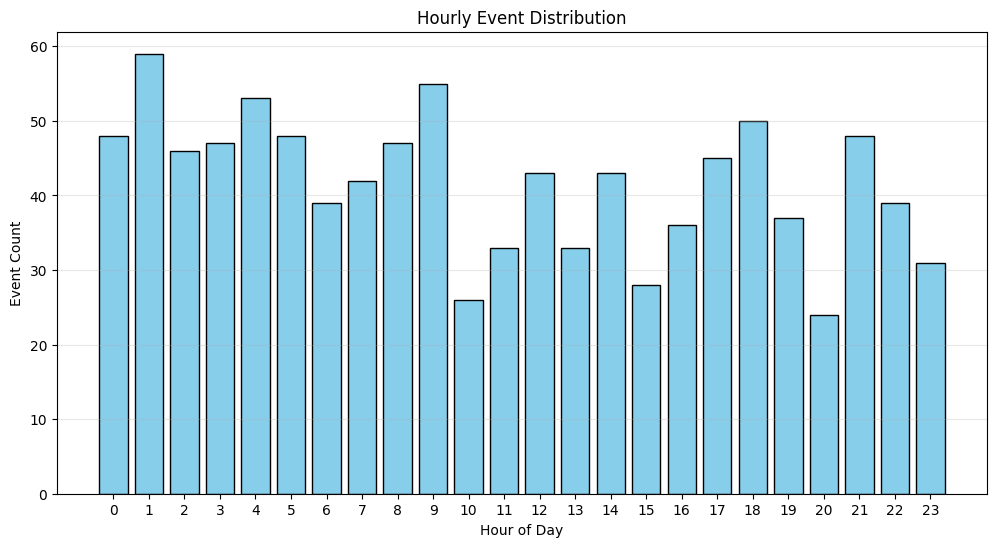

In [59]:
# Step 8: Hourly Pattern
print("\nStep 8: Hourly Pattern")

raw_user_interactions['hour_of_day'] = raw_user_interactions['event_timestamp'].dt.hour
hourly_pattern = raw_user_interactions.groupby('hour_of_day').size().reset_index(name='event_count')
hourly_pattern['pct'] = (hourly_pattern['event_count'] / hourly_pattern['event_count'].sum() * 100).round(2)

print("Hourly Pattern:")
display(hourly_pattern)

# Visualize hourly pattern
plt.figure(figsize=(12, 6))
plt.bar(hourly_pattern['hour_of_day'], hourly_pattern['event_count'], color='skyblue', edgecolor='black')
plt.xlabel('Hour of Day')
plt.ylabel('Event Count')
plt.title('Hourly Event Distribution')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.show()


In [60]:
# Step 9: Freshness Check
print("\nStep 9: Freshness Check")

latest_event = raw_user_interactions['event_timestamp'].max()
latest_load = raw_user_interactions['_loaded_at'].max()
current_time = datetime.now()

event_staleness = (current_time - latest_event).total_seconds() / 3600
load_staleness = (current_time - latest_load).total_seconds() / 3600

print(f"Latest event: {latest_event}")
print(f"Latest load: {latest_load}")
print(f"Event staleness: {event_staleness:.1f} hours")
print(f"Load staleness: {load_staleness:.1f} hours")


Step 9: Freshness Check
Latest event: 2026-03-23 17:00:09.610638
Latest load: 2026-03-23 17:04:36.610638
Event staleness: 1.6 hours
Load staleness: 1.5 hours


In [61]:
## Iteration 4: Cross-Table Profiling (10 minutes)
# Step 10: Referential Completeness
print("\nStep 10: Referential Completeness")

# Clean data for join
raw_clean = raw_user_interactions[raw_user_interactions['user_id'].notna() & (raw_user_interactions['user_id'] != '')]

orphan_analysis = raw_clean.merge(dim_users, on='user_id', how='left', indicator=True)
orphan_rate = (orphan_analysis['_merge'] == 'left_only').sum() / len(orphan_analysis) * 100

print(f"Total events with user_id: {len(orphan_analysis):,}")
print(f"Orphan events (users not in dim_users): {(orphan_analysis['_merge'] == 'left_only').sum():,}")
print(f"Orphan rate: {orphan_rate:.2f}%")


Step 10: Referential Completeness
Total events with user_id: 1,000
Orphan events (users not in dim_users): 0
Orphan rate: 0.00%


In [62]:
# Step 11: Engagement Score Validation
print("\nStep 11: Engagement Score Validation")

engagement_stats = {
    'total_rows': len(fct_daily_engagement),
    'min_score': fct_daily_engagement['engagement_score'].min(),
    'max_score': fct_daily_engagement['engagement_score'].max(),
    'avg_score': fct_daily_engagement['engagement_score'].mean(),
    'below_zero': (fct_daily_engagement['engagement_score'] < 0).sum(),
    'above_hundred': (fct_daily_engagement['engagement_score'] > 100).sum(),
    'zero_events': (fct_daily_engagement['total_events'] == 0).sum()
}

print("Engagement Score Validation:")
for key, value in engagement_stats.items():
    print(f"  {key}: {value:,}" if isinstance(value, (int, float)) else f"  {key}: {value}")


Step 11: Engagement Score Validation
Engagement Score Validation:
  total_rows: 182
  min_score: 0.0
  max_score: 100.0
  avg_score: 82.6923076923077
  below_zero: 0
  above_hundred: 0
  zero_events: 0


In [65]:
## Iteration 5: Compile the Report (5 minutes)
# Step 12: Final Profiling Report
# Compile all findings into a structured report
report = f"""
{'='*70}
STREAMPULSE DATA PROFILING REPORT
{'='*70}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Period: Last 30 days
Analyst: Data Engineering Team

{'─'*70}
1. DATASET OVERVIEW
{'─'*70}
Tables profiled: 3
  raw_user_interactions: {len(raw_user_interactions):,} rows
  dim_users: {len(dim_users):,} rows
  fct_daily_engagement: {len(fct_daily_engagement):,} rows

{'─'*70}
2. COMPLETENESS
{'─'*70}
"""

# Add completeness table
for _, row in completeness_df.iterrows():
    report += f"  {row['Column']:<15} {row['Null %']:>6}%    {row['Empty %']:>6}    {row['Total Missing %']:>6}%    {row['Status']:<12} {row['Recommendation']}\n"

report += f"""
{'─'*70}
3. UNIQUENESS & CARDINALITY
{'─'*70}
  Total rows: {cardinality_results['total_rows'].iloc[0]:,}
  Unique users: {cardinality_results['distinct_users'].iloc[0]:,}
  User cardinality: {cardinality_results['user_id_cardinality'].iloc[0]:.4f}
  Unique actions: {cardinality_results['distinct_actions'].iloc[0]}
  Unique content: {cardinality_results['distinct_content'].iloc[0]:,}
  Unique devices: {cardinality_results['distinct_devices'].iloc[0]}
  Unique countries: {cardinality_results['distinct_countries'].iloc[0]}

{'─'*70}
4. DISTRIBUTION
{'─'*70}
  Numeric (amount):
    Min: ${numeric_results['min_amount'].iloc[0]:.2f}
    Max: ${numeric_results['max_amount'].iloc[0]:.2f}
    Mean: ${numeric_results['mean_amount'].iloc[0]:.2f}
    Median: ${numeric_results['median'].iloc[0]:.2f}
    Std Dev: ${numeric_results['stddev_amount'].iloc[0]:.2f}
    Negative values: {numeric_results['negative_count'].iloc[0]}

  Categorical Distribution:
    Actions: {', '.join([f"{row['action']}({row['pct']}%)" for _, row in action_results.head(3).iterrows()])}
    Devices: {', '.join([f"{row['device']}({row['pct']}%)" for _, row in device_results.head(3).iterrows()])}
    Top Countries: {', '.join([f"{row['country']}({row['pct']}%)" for _, row in country_results.head(3).iterrows()])}

{'─'*70}
5. TEMPORAL PATTERNS
{'─'*70}
  Daily volume: avg {daily_trend['daily_events'].mean():.0f}, min {daily_trend['daily_events'].min():.0f}, max {daily_trend['daily_events'].max():.0f}
  Peak hour: {hourly_pattern.loc[hourly_pattern['event_count'].idxmax(), 'hour_of_day']}:00 ({hourly_pattern['event_count'].max():,} events)
  Weekend effect: TBD (analyze weekend vs weekday patterns)

{'─'*70}
6. FRESHNESS
{'─'*70}
  Event staleness: {event_staleness:.1f} hours
  Load staleness: {load_staleness:.1f} hours

{'─'*70}
7. CROSS-TABLE INTEGRITY
{'─'*70}
  Orphan event rate: {orphan_rate:.2f}%
  Engagement score validation: {engagement_stats['below_zero']} below zero, {engagement_stats['above_hundred']} above 100

{'─'*70}
8. RECOMMENDED VALIDATION RULES
{'─'*70}
  1. event_id must be NOT NULL and UNIQUE
  2. user_id should have <5% missing values
  3. amount must be >=0 for all transactions
  4. action must be in allowed set: play, like, skip, share, purchase, refund
  5. engagement_score must be between 0 and 100

{'─'*70}
9. RECOMMENDED ANOMALY THRESHOLDS
{'─'*70}
  1. Daily volume: ±30% from 7-day moving average
  2. Hourly volume: ±50% from average for that hour
  3. Revenue: ±20% from previous day

{'─'*70}
10. ISSUES FOUND
{'─'*70}
"""

# Add issues found
issues = []
if completeness_df[completeness_df['Total Missing %'] > 20].shape[0] > 0:
    issues.append(f"⚠️ High missing rate in columns: {', '.join(completeness_df[completeness_df['Total Missing %'] > 20]['Column'].tolist())}")

if orphan_rate > 5:
    issues.append(f"⚠️ High orphan rate: {orphan_rate:.1f}% of events reference non-existent users")

if engagement_stats['below_zero'] > 0:
    issues.append(f"❌ {engagement_stats['below_zero']} records have engagement_score below 0")

if engagement_stats['above_hundred'] > 0:
    issues.append(f"❌ {engagement_stats['above_hundred']} records have engagement_score above 100")

if numeric_results['negative_count'].iloc[0] > 0:
    issues.append(f"⚠️ {numeric_results['negative_count'].iloc[0]} records have negative amounts")

if not issues:
    issues.append("✅ No critical issues found")

for issue in issues:
    report += f"  {issue}\n"

report += f"""
{'='*70}
END OF REPORT
{'='*70}
"""

print(report)


NameError: name 'numeric_results' is not defined